/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


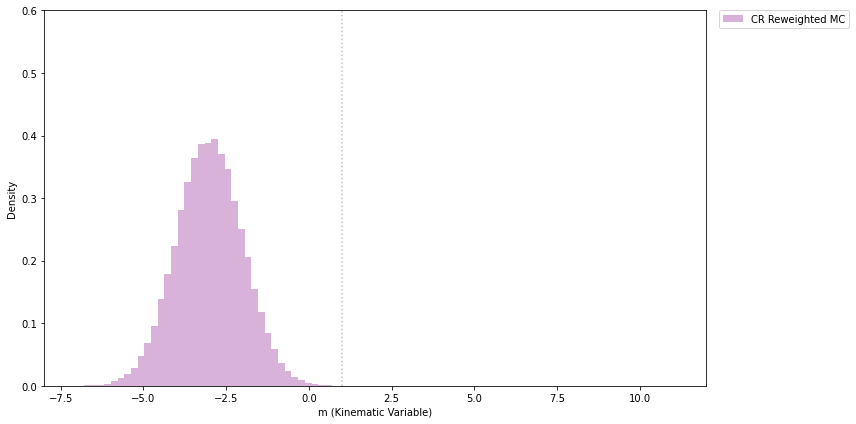

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducible data
np.random.seed(42)
n_events = 100000

# ==========================================
# 1. Generate Toy Data (Purely Conceptual Mock)
# ==========================================
# CR Distributions
cr_data = np.random.normal(loc=-3.0, scale=1.0, size=n_events)
cr_mc = np.random.normal(loc=-2.0, scale=1.4, size=n_events)

# Conceptual Reweighted CR: Matches data parameters exactly.
# We generate a fresh sample so the statistical noise doesn't look artificially identical.
cr_reweighted_mc = np.random.normal(loc=-3.0, scale=1.0, size=n_events)

# SR Distributions
sr_data = np.random.normal(loc=5.0, scale=1.5, size=n_events)
sr_mc = np.random.normal(loc=6.5, scale=2.0, size=n_events)

# Conceptual Reweighted SR: Pulled towards data, but not perfectly matching.
# Represents the "learned" correction being applied imperfectly to a new region.
sr_reweighted_mc = np.random.normal(loc=5.4, scale=1.7, size=n_events)

# ==========================================
# 2. Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(12, 6))
bins = np.linspace(-8, 12, 100)

def plot_data_with_errors(ax, data, bins, color, label):
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    err_counts = np.sqrt(counts) # Poisson error
    
    # Normalize to density
    area = np.sum(counts * bin_widths)
    density = counts / area
    err_density = err_counts / area
    
    mask = counts > 0
    ax.errorbar(bin_centers[mask], density[mask], yerr=err_density[mask], 
                fmt='o', color=color, label=label, markersize=4, capsize=0)

# Plot CR
# plot_data_with_errors(ax, cr_data, bins, 'forestgreen', 'CR Data')
# ax.hist(cr_mc, bins=bins, density=True, histtype='step', color='darkorange', 
        # linestyle='--', linewidth=2, label='CR MC')
ax.hist(cr_reweighted_mc, bins=bins, density=True, histtype='stepfilled', 
        color='purple', alpha=0.3, label='CR Reweighted MC')

# # Plot SR
# plot_data_with_errors(ax, sr_data, bins, 'steelblue', 'SR Data')
# ax.hist(sr_mc, bins=bins, density=True, histtype='step', color='skyblue', 
#         linestyle='--', linewidth=2, label='SR MC')
# ax.hist(sr_reweighted_mc, bins=bins, density=True, histtype='stepfilled', 
#         color='firebrick', alpha=0.3, label='SR Reweighted MC')

# Aesthetics
ax.axvline(1, color='grey', linestyle=':', alpha=0.5) 
ax.set_xlabel('m (Kinematic Variable)')
ax.set_ylabel('Density')
# ax.set_title('Conceptual Mock: Reweighting (No ML Training)')
ax.set_xlim(-8, 12)
ax.set_ylim(0, 0.6)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()

In [ ]:
# # ============================================================
# # 2D EXCLUSION MAPS
# # ============================================================

import os
import sys
import yaml
import joblib
import torch
import pyhf

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
from sklearn.metrics import roc_curve

helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

# ============================================================
# FORCE CPU
# ============================================================

os.environ["CUDA_VISIBLE_DEVICES"] = ""

# ============================================================
# USER CONFIG
# ============================================================

SELECTIONS = ["ATLAS"]  # Run only ML selection for now to save time

# Uncomment points to get a full, edge-to-edge contour map
SIGNAL_MODES = [
    # "1000_2",
    # "1000_4",
    "1000_6",
    "1000_8",
    # "2000_2",
    "2000_4",
    "2000_6",
    # "2000_8",
    "3000_2",
    "3000_4",
    # "3000_6",
    # "3000_8",
]

CLASSIFIER_RUNS = 20
DEVICE = "cpu"

LUMI = 25.3845
N_GEN = 100000

OUTPUT_BASE = "/home/aegis/ether/Research_HEP/NRAD/Signal/replicate_atlas"
SCALER_PATH = "Final_Dataset_ATLAS/minmax_scaler.joblib"
CONFIG_PATH = "/home/aegis/Titan1/NRAD/data/configs/bc_discrim.yml"

MJJ_BINS = np.linspace(1000, 4000, 31)

# ============================================================
# LOAD SCALER
# ============================================================

scaler = joblib.load(SCALER_PATH)

# ============================================================
# FEATURES
# ============================================================

features_to_scale = [
    "met_recalc_pt", "ht", "mjj",
    "ljet1_tau21", "ljet1_tau32",
    "ljet2_tau21", "ljet2_tau32",
]

features = [
    "mjj", "ljet1_tau21", "ljet1_tau32",
    "ljet2_tau21", "ljet2_tau32",
]

# ============================================================
# METADATA
# ============================================================

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0},

    {"Mass": 2000, "Rinv": 2, "XS": 146.3},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3},

    {"Mass": 3000, "Rinv": 2, "XS": 14.24},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26},
]

DF_META = pd.DataFrame(METADATA_LIST)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_metadata(mode):
    mass, rinv = map(int, mode.split("_"))
    row = DF_META[(DF_META["Mass"] == mass) & (DF_META["Rinv"] == rinv)]
    return row.iloc[0]["XS"]

def apply_sr_cuts(df):
    return df.filter(
        (pl.col("ht") > 600) & 
        (pl.col("met_recalc_pt") > 600) & 
        (pl.col("met_recalc_pt") < 2000) & 
        (pl.col("mjj") < 10000) & 
        (pl.col("ht") < 4000)
    )

def unscale_dataframe(df, fitted_scaler, features):
    X_scaled = df.select(features).to_numpy()
    X_physical = fitted_scaler.inverse_transform(X_scaled)
    unscaled_series = [pl.Series(name=f, values=X_physical[:, i]) for i, f in enumerate(features)]
    return df.with_columns(unscaled_series)

def load_signal_for_cwola(mode_str):
    COLS = [
        "pT_j1", "eta_j1", "phi_j1", "pT_j2", "eta_j2", "phi_j2",
        "m_jj", "sm_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2",
        "met", "phi_met", "min_dPhi", "ht", "pt_balance", "delta_phi_j1j2", "weight"
    ]
    file_path = os.path.join(OUTPUT_BASE, f"{mode_str}_events_markXI.txt")
    df_sim = pd.read_csv(file_path, sep=r"\s+", names=COLS, skiprows=1)
    
    xs = get_metadata(mode_str)
    norm_factor = (xs * LUMI) / N_GEN
    df_sim["weight"] = norm_factor
    
    rename_mapping = {
        "m_jj": "mjj", "tau21_j1": "ljet1_tau21", "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21", "tau32_j2": "ljet2_tau32", "met": "met_recalc_pt",
    }
    return pl.from_pandas(df_sim.rename(columns=rename_mapping))

def run_ensemble_inference(X, eval_dir, code_prefix):
    all_scores = np.zeros((len(X), CLASSIFIER_RUNS))
    for i in range(CLASSIFIER_RUNS):
        model_path = os.path.join(eval_dir, f"model_{code_prefix}_run{i}.pt")
        NN = torch.load(model_path, map_location=DEVICE, weights_only=False)
        NN.model.eval()
        all_scores[:, i] = NN.evaluation(X).flatten()
    return np.median(all_scores, axis=1)

def find_limit(scan_values, cls_values, threshold=0.05):
    cls_vals_flat = np.array([float(val) for val in cls_values])
    return np.interp(threshold, cls_vals_flat[::-1], scan_values[::-1])

# ============================================================
# MAIN LOOP
# ============================================================

results = []

for selection in SELECTIONS:
    print("\n" + "=" * 60)
    print(f"RUNNING SELECTION: {selection}")
    print("=" * 60)

    # LOAD SR DATA
    df_mc = pl.read_parquet(f"AD_Events/SR_events_mc_{selection}.parquet")
    df_data = pl.read_parquet(f"AD_Events/SR_events_data_{selection}.parquet")

    # UNSCALE
    df_mc_physical = unscale_dataframe(df_mc, scaler, features_to_scale)
    df_data_physical = unscale_dataframe(df_data, scaler, features_to_scale)

    # PREPARE BKG + DATA
    X_bkg_scaled = df_mc.select(features).to_numpy()
    X_data_scaled = df_data.select(features).to_numpy()
    eval_dir = f"Eval_CWoLa_SR_{selection}"
    code_prefix = f"Data_vs_Extrap_{selection}"

    # RUN BACKGROUND + DATA ONCE
    print("Running background inference...")
    final_bkg_scores = run_ensemble_inference(X_bkg_scaled, eval_dir, code_prefix)
    final_data_scores = run_ensemble_inference(X_data_scaled, eval_dir, code_prefix)

    # ATTACH SCORES
    df_mc_physical = df_mc_physical.with_columns(pl.Series(name="cwola_score", values=final_bkg_scores))
    df_data_physical = df_data_physical.with_columns(pl.Series(name="cwola_score", values=final_data_scores))

    # SIGNAL LOOP
    for signal_mode in SIGNAL_MODES:
        print(f"\nProcessing {signal_mode}")
        try:
            # Setup dynamic mu scan bounds based on expected signal mass limits
            mass, rinv = map(int, signal_mode.split("_"))
            if mass >= 3000:
                mu_max = 500.0
            elif mass >= 2000:
                mu_max = 50.0
            else:
                mu_max = 5.0

            # LOAD & SCALE SIGNAL
            df_signal = apply_sr_cuts(load_signal_for_cwola(signal_mode))
            X_signal_scaled_full = scaler.transform(df_signal.select(features_to_scale).to_numpy())
            X_signal_scaled = X_signal_scaled_full[:, [features_to_scale.index(f) for f in features]]

            # SIGNAL INFERENCE
            final_signal_scores = run_ensemble_inference(X_signal_scaled, eval_dir, code_prefix)
            df_signal = df_signal.with_columns(pl.Series(name="cwola_score", values=final_signal_scores))

            # APPLY CUT
            cut_threshold = np.percentile(final_bkg_scores, 95)
            pass_bkg = df_mc_physical.filter(pl.col("cwola_score") > cut_threshold)
            pass_data = df_data_physical.filter(pl.col("cwola_score") > cut_threshold)
            pass_sig = df_signal.filter(pl.col("cwola_score") > cut_threshold)

            # HISTOGRAMS
            hist_bkg, _ = np.histogram(pass_bkg["mjj"].to_numpy(), bins=MJJ_BINS, weights=pass_bkg["extrapolated_SR_weight"].to_numpy())
            hist_data, _ = np.histogram(pass_data["mjj"].to_numpy(), bins=MJJ_BINS)
            hist_sig, _ = np.histogram(pass_sig["mjj"].to_numpy(), bins=MJJ_BINS, weights=pass_sig["weight"].to_numpy())
            hist_bkg_var, _ = np.histogram(pass_bkg["mjj"].to_numpy(), bins=MJJ_BINS, weights=pass_bkg["extrapolated_SR_weight"].to_numpy() ** 2)

            # SAFE HISTOGRAMS
            epsilon = 1e-6
            hist_bkg_safe = np.where(hist_bkg <= 0, epsilon, hist_bkg)
            hist_bkg_var_safe = np.where(hist_bkg_var <= 0, epsilon, hist_bkg_var)

            # PYHF MODEL
            model_spec = {
                "channels": [{"name": "SR_mjj", "samples": [
                    {"name": "Background", "data": hist_bkg_safe.tolist(), "modifiers": [{"name": "stat_uncert", "type": "staterror", "data": np.sqrt(hist_bkg_var_safe).tolist()}]},
                    {"name": "Signal", "data": hist_sig.tolist(), "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]}
                ]}],
                "observations": [{"name": "SR_mjj", "data": hist_data.tolist()}],
                "measurements": [{"name": "Limit", "config": {"poi": "mu", "parameters": [{"name": "mu", "bounds": [[0.0, mu_max]]}]}}],
                "version": "1.0.0"
            }

            workspace = pyhf.Workspace(model_spec)
            model = workspace.model()
            data_ws = workspace.data(model)

            # LIMIT SCAN
            mu_scan = np.linspace(0.01, mu_max, 150)
            obs_cls_list, exp_cls_list = [], []

            for mu in mu_scan:
                obs, exp = pyhf.infer.hypotest(float(mu), data_ws, model, test_stat="qtilde", return_expected_set=True)
                obs_cls_list.append(obs)
                exp_cls_list.append(exp)

            obs_cls = np.array(obs_cls_list)
            exp_cls_set = np.array(exp_cls_list).T

            obs_limit = find_limit(mu_scan, obs_cls)
            exp_m2 = find_limit(mu_scan, exp_cls_set[0])
            exp_m1 = find_limit(mu_scan, exp_cls_set[1])
            exp_med = find_limit(mu_scan, exp_cls_set[2])
            exp_p1 = find_limit(mu_scan, exp_cls_set[3])
            exp_p2 = find_limit(mu_scan, exp_cls_set[4])

            # STORE RESULTS
            xs = get_metadata(signal_mode)
            results.append({
                "selection": selection, "mass": mass, "rinv": rinv,
                "obs_limit": obs_limit, "exp_limit": exp_med,
                "exp_p1": exp_p1, "exp_m1": exp_m1, "exp_p2": exp_p2, "exp_m2": exp_m2,
                "xs": xs, "obs_xs_limit": obs_limit * xs, "exp_xs_limit": exp_med * xs,
            })
            print(f"Expected μ limit: {exp_med:.3f}")

        except Exception as e:
            print(f"FAILED: {signal_mode} -> {e}")

# ============================================================
# SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(results)
results_df.to_csv(f"cwola_2d_limit_scan_{selection}.csv", index=False)
print("\nSaved results to cwola_2d_limit_scan.csv")


RUNNING SELECTION: ML
Running background inference...

Processing 1000_6


/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


Expected μ limit: 0.493

Processing 1000_8


/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


Expected μ limit: 0.408

Processing 2000_4


...

Expected μ limit: 3.837

Processing 3000_2


/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


Expected μ limit: 195.466

Processing 3000_4


/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


Expected μ limit: 81.409

Saved results to cwola_2d_limit_scan.csv


/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


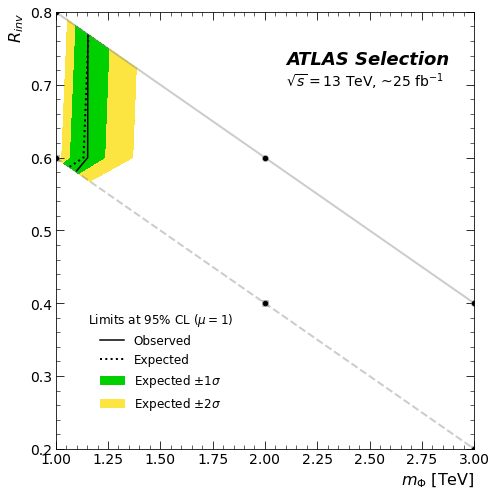

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

selection = "ATLAS"

# 1. Load your DataFrame
results_df = pd.read_csv(f"cwola_2d_limit_scan_{selection}.csv")

# 2. Extract unique grid coordinates
masses = sorted(results_df["mass"].unique())
rinvs = sorted(results_df["rinv"].unique())

# Create a sparse 2D grid based ONLY on your simulated points
X, Y = np.meshgrid(masses, rinvs)

# Initialize Z grids with NaNs
Z_obs = np.full(X.shape, np.nan)
Z_exp = np.full(X.shape, np.nan)
Z_m2  = np.full(X.shape, np.nan)
Z_m1  = np.full(X.shape, np.nan)
Z_p1  = np.full(X.shape, np.nan)
Z_p2  = np.full(X.shape, np.nan)

# Fill the grids with your actual data
for i, rinv in enumerate(rinvs):
    for j, mass in enumerate(masses):
        row = results_df[(results_df["mass"] == mass) & (results_df["rinv"] == rinv)]
        if not row.empty:
            Z_obs[i, j] = row["obs_limit"].values[0]
            Z_exp[i, j] = row["exp_limit"].values[0]
            Z_m2[i, j]  = row["exp_m2"].values[0]
            Z_m1[i, j]  = row["exp_m1"].values[0]
            Z_p1[i, j]  = row["exp_p1"].values[0]
            Z_p2[i, j]  = row["exp_p2"].values[0]

# Convert for plotting axes (TeV and 0.X)
X_plot = X / 1000.0
Y_plot = Y / 10.0

# 3. Setup the Plot
fig, ax = plt.subplots(figsize=(7, 7))

# =====================================================================
# THE RAW LAYERING TRICK
# Because we are using the sparse X_plot/Y_plot grids, Matplotlib will 
# natively draw straight, jagged lines between the crossing points.
# =====================================================================

ax.contourf(X_plot, Y_plot, Z_m2, levels=[0, 1.0], colors=['#FDE541'])
ax.contourf(X_plot, Y_plot, Z_m1, levels=[0, 1.0], colors=['#00D000'])
ax.contourf(X_plot, Y_plot, Z_p1, levels=[0, 1.0], colors=['#FDE541'])
ax.contourf(X_plot, Y_plot, Z_p2, levels=[0, 1.0], colors=['white'])

# Draw the Hard Lines
ax.contour(X_plot, Y_plot, Z_exp, levels=[1.0], colors='black', linestyles=':', linewidths=2)
ax.contour(X_plot, Y_plot, Z_obs, levels=[1.0], colors='black', linestyles='-', linewidths=1.5)

# =====================================================================
# DRAW THE "DOTS"
# Plot the exact points you simulated so you can see the skeleton
# =====================================================================
simulated_masses = results_df['mass'].values / 1000.0
simulated_rinvs = results_df['rinv'].values / 10.0

ax.scatter(simulated_masses, simulated_rinvs, color='black', s=20, zorder=5)


# 4. Styling and Formatting
ax.set_xlabel(r'$m_\Phi$ [TeV]', fontsize=16, loc='right')
ax.set_ylabel(r'$R_{inv}$', fontsize=16, loc='top')

ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=8, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True)
ax.minorticks_on()

# ===========
# Plot Lines
# ===========

# Line 1 Data (m, rinv)
m_line1 = [1.0, 2.0, 3.0]
rinv_line1 = [0.8, 0.6, 0.4]

# Line 2 Data (m, rinv)
m_line2 = [1.0, 2.0, 3.0]
rinv_line2 = [0.6, 0.4, 0.2]

# Draw Line 1 (Solid blue line with circular markers)
ax.plot(m_line1, rinv_line1, marker='o', linestyle='-', color='grey', linewidth=2, alpha=0.4)

# Draw Line 2 (Dashed red line with square markers)
ax.plot(m_line2, rinv_line2, marker='s', linestyle='--', color='grey', linewidth=2, alpha=0.4)



ax.text(0.55, 0.88, 'ATLAS Selection', transform=ax.transAxes, fontsize=18, fontweight='bold', style='italic')
ax.text(0.55, 0.83, r'$\sqrt{s} = 13$ TeV, ~25 fb$^{-1}$', transform=ax.transAxes, fontsize=14)
# ax.text(0.55, 0.75, 'Raw Connected Limit', transform=ax.transAxes, fontsize=12)




legend_elements = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Observed'),
    Line2D([0], [0], color='black', lw=2, linestyle=':', label='Expected'),
    mpatches.Patch(color='#00D000', label=r'Expected $\pm 1\sigma$'),
    mpatches.Patch(color='#FDE541', label=r'Expected $\pm 2\sigma$'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=6, label='Simulated Points')
]

ax.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.45, 0.2), 
          frameon=False, fontsize=12, title="Limits at 95% CL ($\mu=1$)", title_fontsize=12)
ax.set_xlim(1, 3)
plt.tight_layout()
plt.show()


Generating plots for ML...


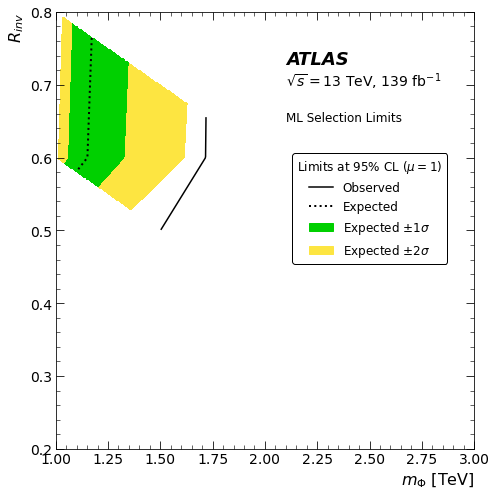

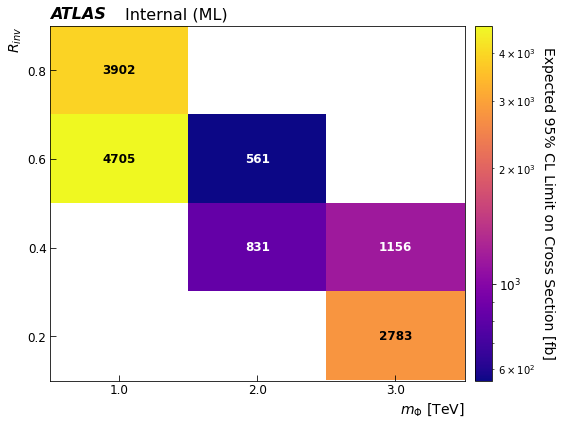

In [55]:
for selection in SELECTIONS:
    print(f"\nGenerating plots for {selection}...")
    subset = results_df[results_df["selection"] == selection]
    if subset.empty: continue

    # --------------------------------------------------------
    # PLOT 1: BRAZILIAN 2D EXCLUSION MAP (MU LIMIT)
    # --------------------------------------------------------
    x = subset['mass'].values / 1000.0  
    y = subset['rinv'].values / 10.0    

    z_obs = subset['obs_limit'].values
    z_exp = subset['exp_limit'].values
    z_m2  = subset['exp_m2'].values
    z_m1  = subset['exp_m1'].values
    z_p1  = subset['exp_p1'].values
    z_p2  = subset['exp_p2'].values

    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    XI, YI = np.meshgrid(xi, yi)

    interp_method = 'linear' 
    ZI_obs = griddata((x, y), z_obs, (XI, YI), method=interp_method)
    ZI_exp = griddata((x, y), z_exp, (XI, YI), method=interp_method)
    ZI_m2  = griddata((x, y), z_m2,  (XI, YI), method=interp_method)
    ZI_m1  = griddata((x, y), z_m1,  (XI, YI), method=interp_method)
    ZI_p1  = griddata((x, y), z_p1,  (XI, YI), method=interp_method)
    ZI_p2  = griddata((x, y), z_p2,  (XI, YI), method=interp_method)

    fig, ax = plt.subplots(figsize=(7, 7))

    # Layering Trick
    ax.contourf(XI, YI, ZI_m2, levels=[0, 1.0], colors=['#FDE541'])
    ax.contourf(XI, YI, ZI_m1, levels=[0, 1.0], colors=['#00D000'])
    ax.contourf(XI, YI, ZI_p1, levels=[0, 1.0], colors=['#FDE541'])
    ax.contourf(XI, YI, ZI_p2, levels=[0, 1.0], colors=['white'])

    # Hard Lines
    ax.contour(XI, YI, ZI_exp, levels=[1.0], colors='black', linestyles=':', linewidths=2)
    ax.contour(XI, YI, ZI_obs, levels=[1.0], colors='black', linestyles='-', linewidths=1.5)

    # Formatting
    ax.set_xlabel(r'$m_\Phi$ [TeV]', fontsize=16, loc='right')
    ax.set_ylabel(r'$R_{inv}$', fontsize=16, loc='top')
    ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=8, top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True)
    ax.minorticks_on()

    ax.text(0.55, 0.88, 'ATLAS', transform=ax.transAxes, fontsize=18, fontweight='bold', style='italic')
    ax.text(0.55, 0.83, r'$\sqrt{s} = 13$ TeV, 139 fb$^{-1}$', transform=ax.transAxes, fontsize=14)
    ax.text(0.55, 0.75, f'{selection} Selection Limits', transform=ax.transAxes, fontsize=12)

    # Framed Legend
    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Observed'),
        Line2D([0], [0], color='black', lw=2, linestyle=':', label='Expected'),
        mpatches.Patch(color='#00D000', label=r'Expected $\pm 1\sigma$'),
        mpatches.Patch(color='#FDE541', label=r'Expected $\pm 2\sigma$')
    ]
    ax.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.95, 0.55), 
              frameon=True, facecolor='white', edgecolor='black', framealpha=1.0, 
              fontsize=12, title="Limits at 95% CL ($\mu=1$)", title_fontsize=12)

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # PLOT 2: CROSS SECTION BINNED BLOCK HEATMAP
    # --------------------------------------------------------
    xs_pivot = subset.pivot(index='rinv', columns='mass', values='exp_xs_limit')
    
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    im = ax2.imshow(
        xs_pivot, origin='lower', cmap='plasma', 
        norm=LogNorm(vmin=xs_pivot.min().min(), vmax=xs_pivot.max().max()), aspect='auto'
    )

    for i in range(xs_pivot.shape[0]):
        for j in range(xs_pivot.shape[1]):
            val = xs_pivot.iloc[i, j]
            if not np.isnan(val):
                text_val = f"{val:.1f}" if val < 100 else f"{val:.0f}"
                midpoint = np.sqrt(xs_pivot.min().min() * xs_pivot.max().max())
                text_color = "black" if val > midpoint else "white"
                ax2.text(j, i, text_val, ha="center", va="center", color=text_color, fontsize=12, fontweight='bold')

    ax2.set_xticks(range(len(xs_pivot.columns)))
    ax2.set_xticklabels(xs_pivot.columns / 1000.0, fontsize=12)
    ax2.set_xlabel(r'$m_\Phi$ [TeV]', fontsize=14, loc='right')

    ax2.set_yticks(range(len(xs_pivot.index)))
    ax2.set_yticklabels(xs_pivot.index / 10.0, fontsize=12)
    ax2.set_ylabel(r'$R_{inv}$', fontsize=14, loc='top')
    ax2.tick_params(axis='both', which='major', direction='in', length=6, top=False, right=False)

    cbar = fig2.colorbar(im, ax=ax2, pad=0.02)
    cbar.set_label('Expected 95% CL Limit on Cross Section [fb]', fontsize=14, rotation=270, labelpad=20)
    cbar.ax.tick_params(labelsize=12)

    ax2.text(0.0, 1.02, 'ATLAS', transform=ax2.transAxes, fontsize=16, fontweight='bold', style='italic')
    ax2.text(0.18, 1.02, f'Internal ({selection})', transform=ax2.transAxes, fontsize=16)

    plt.tight_layout()
    plt.show()

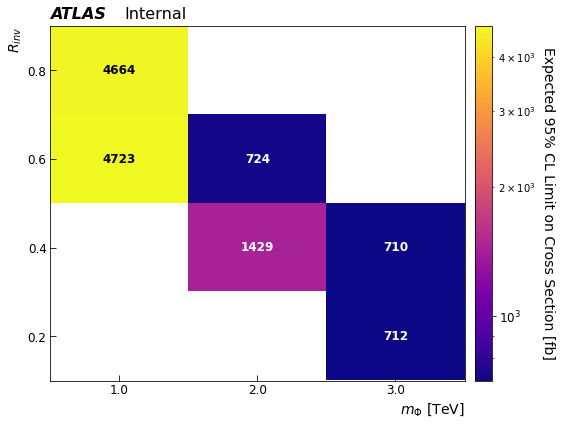

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Load Data
results_df = pd.read_csv("cwola_2d_limit_scan.csv")

# 2. Pivot the data into a 2D matrix
# This automatically handles the grid layout, placing NaNs where data is missing
xs_pivot = results_df.pivot(index='rinv', columns='mass', values='exp_xs_limit')

# 3. Setup Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Draw the block heatmap using a logarithmic color scale
im = ax.imshow(
    xs_pivot, 
    origin='lower', 
    cmap='plasma', 
    norm=LogNorm(vmin=xs_pivot.min().min(), vmax=xs_pivot.max().max()),
    aspect='auto'
)

# 4. Add text annotations inside the boxes
for i in range(xs_pivot.shape[0]):
    for j in range(xs_pivot.shape[1]):
        val = xs_pivot.iloc[i, j]
        if not np.isnan(val):
            # Format numbers cleanly (no decimals for huge numbers)
            text_val = f"{val:.1f}" if val < 100 else f"{val:.0f}"
            
            # Determine text color based on cell brightness so it stays readable
            # Plasma gets bright (yellow) at high values and dark (purple) at low values
            midpoint = np.sqrt(xs_pivot.min().min() * xs_pivot.max().max())
            text_color = "black" if val > midpoint else "white"
            
            ax.text(j, i, text_val, ha="center", va="center", 
                    color=text_color, fontsize=12, fontweight='bold')

# 5. Styling and Formatting
# Set ticks to exactly match our matrix columns/rows
ax.set_xticks(range(len(xs_pivot.columns)))
ax.set_xticklabels(xs_pivot.columns / 1000.0, fontsize=12) # Convert to TeV
ax.set_xlabel(r'$m_\Phi$ [TeV]', fontsize=14, loc='right')

ax.set_yticks(range(len(xs_pivot.index)))
ax.set_yticklabels(xs_pivot.index / 10.0, fontsize=12)     # Convert to 0.X
ax.set_ylabel(r'$R_{inv}$', fontsize=14, loc='top')

# Standard HEP Tick Marks
ax.tick_params(axis='both', which='major', direction='in', length=6, top=False, right=False)

# Add Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Expected 95% CL Limit on Cross Section [fb]', fontsize=14, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=12)

# ATLAS Formatting (Above the plot so it doesn't overlap the boxes)
ax.text(0.0, 1.02, 'ATLAS', transform=ax.transAxes, fontsize=16, fontweight='bold', style='italic')
ax.text(0.18, 1.02, 'Internal', transform=ax.transAxes, fontsize=16)

plt.tight_layout()
plt.show()